In [1]:
import torch
from torch import nn
from torchvision import datasets
from torchvision.transforms import ToTensor
from tqdm.auto import tqdm
import matplotlib.pylab as plt


c:\Users\Samin Chandeepa\Desktop\cnn\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

### Lets generate a sample image to see what the data looks like.

In [3]:
torch.manual_seed(12)

images =  torch.randn(size=(32 , 3 , 64 , 64))
test_image =  images[0]

print(f"Image batch shape: {images.shape} -> [batch_size, color_channels, height, width]")
print(f"Single image shape: {test_image.shape} -> [color_channels, height, width]") 
print(f"Single image pixel values:\n{test_image}")

Image batch shape: torch.Size([32, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Single image shape: torch.Size([3, 64, 64]) -> [color_channels, height, width]
Single image pixel values:
tensor([[[-0.1320, -0.1254,  0.3443,  ...,  0.9739, -1.8436, -0.4994],
         [-1.4684,  0.9004,  0.2897,  ..., -0.0489, -0.3272, -0.5254],
         [ 0.7471, -0.0840,  0.4842,  ...,  1.1429, -1.9101,  0.5553],
         ...,
         [ 2.4900,  2.4456, -1.8108,  ..., -0.8318, -0.7946, -0.2158],
         [ 0.1050,  1.2332,  1.3105,  ...,  0.3585,  1.3716,  0.0848],
         [ 1.7557, -0.2622,  0.8958,  ...,  0.3450,  0.8932,  0.9645]],

        [[-1.5321,  0.9193,  0.9021,  ..., -0.7189,  1.6873, -2.4620],
         [ 1.8277,  1.2801,  2.4342,  ...,  1.1894, -0.2093,  1.6378],
         [ 1.1319, -0.4133,  1.1379,  ...,  0.9042, -0.1073,  1.1811],
         ...,
         [ 0.1458, -0.9947, -0.6316,  ...,  0.3625, -0.6573,  1.3259],
         [ 1.3873, -0.1478,  1.1035,  ...,  1.4180,  1.0126,

nn.Conv2d() layer expects a 4-dimensional tensor as input with size (N, C, H, W) or [batch_size, color_channels, height, width].

Right now our single image test_image only has a shape of [color_channels, height, width] or [3, 64, 64].

We can fix this for a single image using test_image.unsqueeze(dim=0) to add an extra dimension for N.

In [4]:
# sample conv layer
torch.manual_seed(12)

conv_layer = nn.Conv2d(
    in_channels=3,
    out_channels=10,
    kernel_size=3,
    stride=1,
    padding=0
)


# [3,64, 64]  -> [N , C , H , W] -> [1 ,3, 64, 64]
conv_out = conv_layer(test_image.unsqueeze(dim=0))
conv_out.shape



torch.Size([1, 10, 62, 62])

In [5]:
# Check out the conv_layer_2 internal parameters
# Here weight is a matrix and bias is a scaler
print(conv_layer.state_dict())

OrderedDict({'weight': tensor([[[[-0.0132, -0.1029, -0.0182],
          [ 0.0335, -0.0352, -0.1435],
          [ 0.0528, -0.0993,  0.0890]],

         [[ 0.0856, -0.1158,  0.0750],
          [ 0.0319,  0.0507,  0.0215],
          [-0.1439,  0.1844,  0.1325]],

         [[-0.1441, -0.0209,  0.0616],
          [-0.1711, -0.1319,  0.1207],
          [ 0.0853, -0.0879, -0.0769]]],


        [[[ 0.0423,  0.0302,  0.0417],
          [-0.0255,  0.1468, -0.0687],
          [-0.0922, -0.0937, -0.1204]],

         [[ 0.0548, -0.1237, -0.1372],
          [ 0.0959,  0.0876, -0.1293],
          [-0.0665, -0.1447,  0.0438]],

         [[-0.0179,  0.1023, -0.1232],
          [-0.0640,  0.1742,  0.1508],
          [ 0.1870,  0.0519,  0.1467]]],


        [[[ 0.1690, -0.1473, -0.1408],
          [ 0.1695,  0.0694,  0.0214],
          [ 0.1429, -0.1623,  0.1377]],

         [[ 0.0978,  0.0653,  0.0315],
          [-0.0451,  0.0832,  0.1513],
          [ 0.0230, -0.0846, -0.0971]],

         [[-0.0101, -

In [6]:
# Get shapes of weight and bias tensors within conv_layer_2
print(f"conv_layer_2 weight shape: \n{conv_layer.weight.shape} -> [out_channels=10, in_channels=3, kernel_size=3]")
print(f"\nconv_layer_2 bias shape: \n{conv_layer.bias.shape} -> [out_channels=10]")

conv_layer_2 weight shape: 
torch.Size([10, 3, 3, 3]) -> [out_channels=10, in_channels=3, kernel_size=3]

conv_layer_2 bias shape: 
torch.Size([10]) -> [out_channels=10]


In [7]:
max_pool_layer = nn.MaxPool2d(kernel_size=2)

In [8]:
# Print out original image shape without and with unsqueezed dimension
print(f"Test image original shape: {test_image.shape}")
print(f"Test image with unsqueezed dimension: {test_image.unsqueeze(dim=0).shape}")

# Pass data through just the conv_layer
test_image_through_conv = conv_layer(test_image.unsqueeze(dim=0))
print(f"Shape after going through conv_layer(): {test_image_through_conv.shape}")

# Pass data through the max pool layer
test_image_through_conv_and_max_pool = max_pool_layer(test_image_through_conv)
print(f"Shape after going through conv_layer() and max_pool_layer(): {test_image_through_conv_and_max_pool.shape}")

Test image original shape: torch.Size([3, 64, 64])
Test image with unsqueezed dimension: torch.Size([1, 3, 64, 64])
Shape after going through conv_layer(): torch.Size([1, 10, 62, 62])
Shape after going through conv_layer() and max_pool_layer(): torch.Size([1, 10, 31, 31])


## Building a Convolutional Neural Network (CNN)
CNN's are known for their capabilities to find patterns in visual data. It follows the typical structure of a convolutional neural network:

Input layer -> [Convolutional layer -> activation layer -> pooling layer] -> Output layer

Where the contents of [Convolutional layer -> activation layer -> pooling layer] can be upscaled and repeated multiple times, depending on requirements.

In [9]:
train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

train_data , test_data

100%|██████████| 26.4M/26.4M [03:34<00:00, 123kB/s] 
100%|██████████| 29.5k/29.5k [00:00<00:00, 67.9kB/s]
100%|██████████| 4.42M/4.42M [00:04<00:00, 907kB/s] 
100%|██████████| 5.15k/5.15k [00:00<00:00, 2.03MB/s]


(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

In [11]:
# class names
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [12]:
train_data.data[0].shape

torch.Size([28, 28])

In [14]:
from torch.utils.data import DataLoader

# Setup the batch size hyperparameter
BATCH_SIZE = 32

train_dataloader =  DataLoader(
    dataset=train_data,
    batch_size=BATCH_SIZE,
    shuffle=True # shuffle data every epoch
)

test_dataloader = DataLoader(
    dataset=test_data,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Let's check out what we've created
print(f"Dataloaders: {train_dataloader, test_dataloader}") 
print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x000001F5A552DC70>, <torch.utils.data.dataloader.DataLoader object at 0x000001F5A5272BA0>)
Length of train dataloader: 1875 batches of 32
Length of test dataloader: 313 batches of 32


### Create a convolutional neural network

In [18]:
class FashionMNISTMModel(nn.Module):

    def __init__(self, input_shape :int , hidden_units:int , output_shape:int ):
        super().__init__()

        # block-1  this will be a conv + actication + pooling layer(MAX pooling)
        self.block_1 = nn.Sequential(

            # conv layer    
            nn.Conv2d(
                in_channels=input_shape,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1,

            ),

            # Relu layer
            nn.ReLU(),

            # conv layer
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1,

            ),
            
            # Relu layer
            nn.ReLU(),

            # Max pooling layer
            nn.MaxPool2d(
                kernel_size=2,
                stride=2,
            )
        )

        # block-2  this will be a conv + actication + pooling layer(MAX pooling)
        self.block_2 = nn.Sequential(

            # conv layer    
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                padding=1,

            ),

            # Relu layer
            nn.ReLU(),

            # conv layer
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                padding=1,

            ),
            
            # Relu layer
            nn.ReLU(),

            # Max pooling layer
            nn.MaxPool2d(
                kernel_size=2,
            )
        )

        # block-3 for the FC layers
        self.block_3 = nn.Sequential(

            # flatter the layers
            nn.Flatten(),

            # FC layer
            nn.Linear(
                in_features=hidden_units*7*7,
                out_features=output_shape,
            )

        )

    # forward function
    def forward(self , x:torch.tensor):

        # pass through the blcok-1
        x = self.block_1(x)

        # pass through the blcok-2
        x = self.block_2(x)

        # pass through the blcok-3
        x = self.block_3(x)

        return x

In [19]:
torch.manual_seed(12)

model = FashionMNISTMModel(input_shape=1,hidden_units=10 , output_shape=len(class_names)).to(device)

model

FashionMNISTMModel(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_3): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [20]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
    train_loss, train_acc = 0, 0
    model.to(device)
    model.train() # put model in training mode
    for batch, (X, y) in enumerate(data_loader):
        # Send data to GPU
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y_true=y,
                                 y_pred=y_pred.argmax(dim=1)) # Go from logits -> pred labels

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

    # Calculate loss and accuracy per epoch and print out what's happening
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")

def test_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
    test_loss, test_acc = 0, 0
    model.to(device)
    model.eval() # put model in eval mode
    # Turn on inference context manager
    with torch.inference_mode(): 
        for X, y in data_loader:
            # Send data to GPU
            X, y = X.to(device), y.to(device)
            
            # 1. Forward pass
            test_pred = model(X)
            
            # 2. Calculate loss and accuracy
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true=y,
                y_pred=test_pred.argmax(dim=1) # Go from logits -> pred labels
            )
        
        # Adjust metrics and print out
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")

In [21]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model.parameters() , lr= 0.1)

In [22]:
# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    """Calculates accuracy between truth labels and predictions.

    Args:
        y_true (torch.Tensor): Truth labels for predictions.
        y_pred (torch.Tensor): Predictions to be compared to predictions.

    Returns:
        [torch.float]: Accuracy value between y_true and y_pred, e.g. 78.45
    """
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

In [24]:
from timeit import default_timer as timer 
def print_train_time(start: float, end: float, device: torch.device = None):
    """Prints difference between start and end time.

    Args:
        start (float): Start time of computation (preferred in timeit format). 
        end (float): End time of computation.
        device ([type], optional): Device that compute is running on. Defaults to None.

    Returns:
        float: time between start and end in seconds (higher is longer).
    """
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

In [25]:
torch.manual_seed(12)

# Measure time
from timeit import default_timer as timer
train_time_start_model_2 = timer()

# Train and test model 
epochs = 3
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    train_step(data_loader=train_dataloader, 
        model=model, 
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn,
        device=device
    )
    test_step(data_loader=test_dataloader,
        model=model,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn,
        device=device
    )

train_time_end_model_2 = timer()
total_train_time_model_2 = print_train_time(start=train_time_start_model_2,
                                           end=train_time_end_model_2,
                                           device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------
Train loss: 0.30160 | Train accuracy: 89.16%


 33%|███▎      | 1/3 [00:51<01:43, 51.92s/it]

Test loss: 0.32353 | Test accuracy: 88.74%

Epoch: 1
---------
Train loss: 0.28944 | Train accuracy: 89.52%


 67%|██████▋   | 2/3 [01:21<00:38, 38.61s/it]

Test loss: 0.33122 | Test accuracy: 88.45%

Epoch: 2
---------
Train loss: 0.27957 | Train accuracy: 89.91%


100%|██████████| 3/3 [01:51<00:00, 37.04s/it]

Test loss: 0.31598 | Test accuracy: 88.77%

Train time on cpu: 111.135 seconds


### Make and evaluate random predictions with best model

In [26]:
def make_predictions(model: torch.nn.Module, data: list, device: torch.device = device):
    pred_probs = []
    model.eval()
    with torch.inference_mode():
        for sample in data:
            # Prepare sample
            sample = torch.unsqueeze(sample, dim=0).to(device) # Add an extra dimension and send sample to device

            # Forward pass (model outputs raw logit)
            pred_logit = model(sample)

            # Get prediction probability (logit -> prediction probability)
            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0) # note: perform softmax on the "logits" dimension, not "batch" dimension (in this case we have a batch size of 1, so can perform on dim=0)

            # Get pred_prob off GPU for further calculations
            pred_probs.append(pred_prob.cpu())
            
    # Stack the pred_probs to turn list into a tensor
    return torch.stack(pred_probs)

In [35]:
import random
random.seed(323232)
test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k=9):
    test_samples.append(sample)
    test_labels.append(label)

# View the first test sample shape and label
print(f"Test sample image shape: {test_samples[0].shape}\nTest sample label: {test_labels[0]} ({class_names[test_labels[0]]})")

Test sample image shape: torch.Size([1, 28, 28])
Test sample label: 8 (Bag)


In [36]:
# Make predictions on test samples with model 2
pred_probs= make_predictions(model=model, 
                             data=test_samples)

# Turn the prediction probabilities into prediction labels by taking the argmax()
pred_classes = pred_probs.argmax(dim=1)
pred_classes

tensor([8, 7, 0, 4, 2, 1, 9, 9, 5])

In [37]:
# Are our predictions in the same form as our test labels? 
test_labels, pred_classes

([8, 7, 0, 4, 4, 1, 9, 9, 5], tensor([8, 7, 0, 4, 2, 1, 9, 9, 5]))

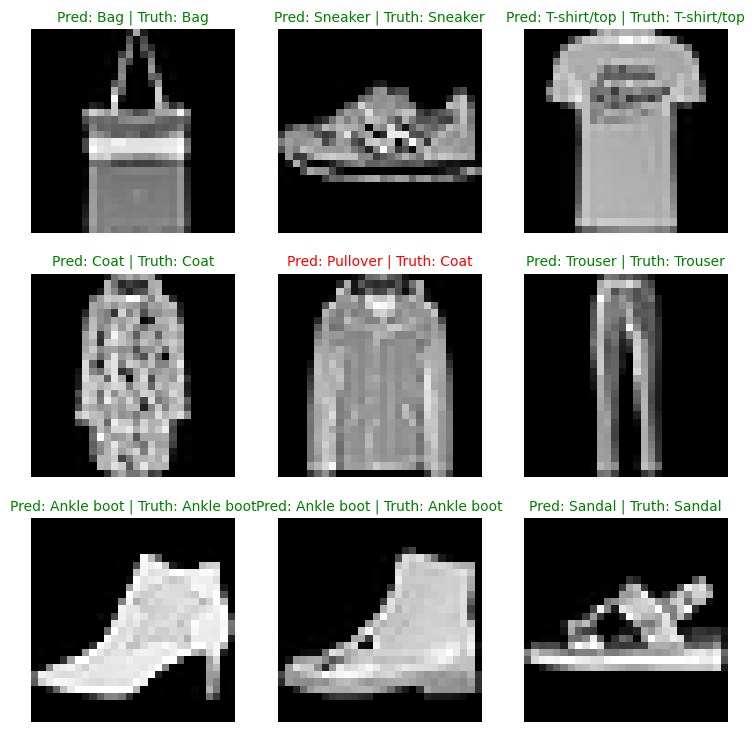

In [38]:
# Plot predictions
plt.figure(figsize=(9, 9))
nrows = 3
ncols = 3
for i, sample in enumerate(test_samples):
  # Create a subplot
  plt.subplot(nrows, ncols, i+1)

  # Plot the target image
  plt.imshow(sample.squeeze(), cmap="gray")

  # Find the prediction label (in text form, e.g. "Sandal")
  pred_label = class_names[pred_classes[i]]

  # Get the truth label (in text form, e.g. "T-shirt")
  truth_label = class_names[test_labels[i]] 

  # Create the title text of the plot
  title_text = f"Pred: {pred_label} | Truth: {truth_label}"
  
  # Check for equality and change title colour accordingly
  if pred_label == truth_label:
      plt.title(title_text, fontsize=10, c="g") # green text if correct
  else:
      plt.title(title_text, fontsize=10, c="r") # red text if wrong
  plt.axis(False);